In [12]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms


### CONFIG :

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 128
num_epochs = 30
learning_rate = 1e-3
lambda_list = [1e-5, 1e-4, 1e-3]
gate_threshold = 1e-2


Using device: cuda


### Dataset & Dataloaders (CIFAR-10)

In [14]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=256, shuffle=False, num_workers=2
)

### Prunable Linear Layer

In [15]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter("bias", None)

        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

        nn.init.constant_(self.gate_scores, 0.0)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def gate_values(self):
        return torch.sigmoid(self.gate_scores).detach()

### MLP using PrunableLinear

In [16]:
class PrunableMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32 * 32 * 3, 1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.fc3 = PrunableLinear(512, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### Helper functions

In [17]:
def compute_sparsity(model, threshold=1e-2):
    all_gates = []
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            g = torch.sigmoid(module.gate_scores).detach().cpu().view(-1)
            all_gates.append(g)
    if not all_gates:
        return 0.0, None
    all_gates = torch.cat(all_gates)
    num_total = all_gates.numel()
    num_pruned = (all_gates < threshold).sum().item()
    sparsity = 100.0 * num_pruned / num_total
    return sparsity, all_gates.numpy()


def evaluate_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100.0 * correct / total


def train_one_model(lambda_coef):
    model = PrunableMLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    print(f"\n=== Training with lambda = {lambda_coef} ===")
    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        running_cls = 0.0
        running_sp = 0.0
        start_time = time.time()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            cls_loss = criterion(logits, labels)

            sparsity_loss = 0.0
            for module in model.modules():
                if isinstance(module, PrunableLinear):
                    gates = torch.sigmoid(module.gate_scores)
                    sparsity_loss = sparsity_loss + gates.sum()

            loss = cls_loss + lambda_coef * sparsity_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_cls  += cls_loss.item() * images.size(0)
            running_sp   += sparsity_loss.item() * images.size(0)

        epoch_time = time.time() - start_time
        train_loss = running_loss / len(trainloader.dataset)
        cls_loss_avg = running_cls / len(trainloader.dataset)
        sp_loss_avg = running_sp / len(trainloader.dataset)

        with torch.no_grad():
            sparsity, _ = compute_sparsity(model, gate_threshold)
        print(
            f"Epoch {epoch:02d} | "
            f"loss={train_loss:.4f} "
            f"(cls={cls_loss_avg:.4f}, sp={sp_loss_avg:.4f}) | "
            f"sparsity={sparsity:.2f}% | "
            f"time={epoch_time:.1f}s"
        )

    test_acc = evaluate_accuracy(model, testloader)
    sparsity, all_gates = compute_sparsity(model, gate_threshold)

    print(
        f"Finished λ={lambda_coef}: "
        f"test_acc={test_acc:.2f}% | sparsity={sparsity:.2f}%"
    )

    return model.state_dict(), test_acc, sparsity, all_gates

Run experiments for multiple lambdas

In [18]:
results = []
best_idx = None

for lam in lambda_list:
    state_dict, acc, sparsity, all_gates = train_one_model(lam)
    results.append({
        "lambda": lam,
        "acc": acc,
        "sparsity": sparsity,
        "state_dict": state_dict,
        "gates": all_gates,
    })

    # Simple \"best\" selection: prioritize accuracy, then sparsity
    if best_idx is None:
        best_idx = 0
    else:
        if acc > results[best_idx]["acc"]:
            best_idx = len(results) - 1


=== Training with lambda = 1e-05 ===
Epoch 01 | loss=18.5356 (cls=1.7836, sp=1675194.5983) | sparsity=0.00% | time=18.3s
Epoch 02 | loss=15.3694 (cls=1.5903, sp=1377905.1496) | sparsity=0.00% | time=17.4s
Epoch 03 | loss=12.8234 (cls=1.5129, sp=1131053.5878) | sparsity=0.00% | time=18.0s
Epoch 04 | loss=10.8033 (cls=1.4545, sp=934876.9606) | sparsity=0.00% | time=18.5s
Epoch 05 | loss=9.2319 (cls=1.4091, sp=782276.3926) | sparsity=0.00% | time=17.4s
Epoch 06 | loss=8.0139 (cls=1.3740, sp=663994.1201) | sparsity=0.00% | time=18.0s
Epoch 07 | loss=7.0597 (cls=1.3429, sp=571682.1677) | sparsity=0.00% | time=18.1s
Epoch 08 | loss=6.3047 (cls=1.3169, sp=498780.4066) | sparsity=0.00% | time=17.6s
Epoch 09 | loss=5.6977 (cls=1.2938, sp=440392.2322) | sparsity=0.00% | time=18.6s
Epoch 10 | loss=5.2022 (cls=1.2724, sp=392983.3971) | sparsity=0.00% | time=17.6s
Epoch 11 | loss=4.7929 (cls=1.2529, sp=353997.2536) | sparsity=0.00% | time=17.5s
Epoch 12 | loss=4.4473 (cls=1.2320, sp=321533.4564) |

### Summary Table and Histogram


=== Summary over lambdas ===
lambda     test_acc (%)    sparsity (%)   
1e-05      58.90           50.99          
0.0001     59.08           91.76          
0.001      51.57           99.80          

Best model (by accuracy): λ=0.0001, acc=59.08%, sparsity=91.76%


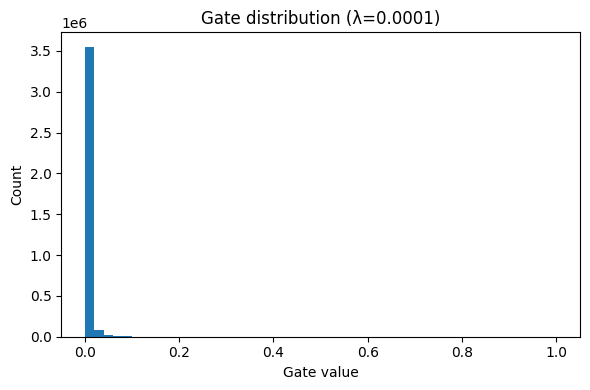

In [19]:
print("\n=== Summary over lambdas ===")
print("{:<10} {:<15} {:<15}".format("lambda", "test_acc (%)", "sparsity (%)"))
for r in results:
    print("{:<10} {:<15.2f} {:<15.2f}".format(r["lambda"], r["acc"], r["sparsity"]))

best = results[best_idx]
print(
    f"\nBest model (by accuracy): λ={best['lambda']}, "
    f"acc={best['acc']:.2f}%, sparsity={best['sparsity']:.2f}%"
)

gates_np = best["gates"]
plt.figure(figsize=(6, 4))
plt.hist(gates_np, bins=50, range=(0.0, 1.0))
plt.xlabel("Gate value")
plt.ylabel("Count")
plt.title(f"Gate distribution (λ={best['lambda']})")
plt.tight_layout()
plt.show()